In [1]:

# =============================================================================
# AI ADOPTION & LABOR MARKET OUTCOMES
# Analyzes BERT-classified job postings to measure AI's impact on
# unemployment, wages, and labor productivity (2021–2025)
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- CONFIG: File Paths ---
FILE_POSTINGS  = 'job_postings_with_predictions (1).csv'
FILE_WAGES     = 'EAR_EMTA_SEX_CUR_NB_A-filtered-2026-06-28.csv'
FILE_GDP       = 'GDP_211P_NOC_NB_A-filtered-2026-06-28.csv'
FILE_UNEMP     = 'SDG_0852_SEX_AGE_RT_A-filtered-2026-06-28.csv'



In [2]:

# =============================================================================
# STEP 1: LOAD & AGGREGATE JOB POSTINGS (BERT Predictions)
# =============================================================================
print("=" * 60)
print("STEP 1 — Job Postings: AI Adoption Intensity by Year")
print("=" * 60)

df = pd.read_csv(FILE_POSTINGS, engine='python', on_bad_lines='warn')

# National-level: one row per year with AI adoption share
ai_by_year = (
    df.groupby('YEAR(POSTED)')
    .agg(
        total_postings=('bert_pred', 'count'),
        ai_postings=('bert_pred', 'sum'),
        ai_intensity=('bert_pred', 'mean')
    )
    .reset_index()
    .rename(columns={'YEAR(POSTED)': 'Year'})
)
print(ai_by_year.to_string(index=False))

# Sector-level breakdown (useful for heterogeneity analysis)
ai_by_sector = (
    df.groupby(['NAICS2_NAME', 'YEAR(POSTED)'])
    .agg(
        total_postings=('bert_pred', 'count'),
        ai_intensity=('bert_pred', 'mean')
    )
    .reset_index()
    .rename(columns={'YEAR(POSTED)': 'Year'})
)


STEP 1 — Job Postings: AI Adoption Intensity by Year


/tmp/ipykernel_1145/1177603336.py:8: ParserWarning: Skipping line 7924: unexpected end of data

  df = pd.read_csv(FILE_POSTINGS, engine='python', on_bad_lines='warn')


 Year  total_postings  ai_postings  ai_intensity
 2019             907            4      0.004410
 2020             898            5      0.005568
 2021            1191           19      0.015953
 2022            1356          382      0.281711
 2023            1066          347      0.325516
 2024             990          239      0.241414
 2025            1122          258      0.229947
 2026             392           90      0.229592


In [3]:

# =============================================================================
# STEP 2: LOAD MACRO INDICATORS (ILO Data)
# =============================================================================
print("\n" + "=" * 60)
print("STEP 2 — Loading Macro Indicators (ILO)")
print("=" * 60)

# Wages: Total, 2021 PPP dollars
wages_df = pd.read_csv(FILE_WAGES)
wages = (
    wages_df[
        (wages_df['sex.label'] == 'Total') &
        (wages_df['classif1.label'] == 'Currency: 2021 PPP $')
    ][['time', 'obs_value']]
    .rename(columns={'time': 'Year', 'obs_value': 'avg_monthly_earnings'})
)

# Productivity: Output per worker, constant 2021 PPP $
gdp_df = pd.read_csv(FILE_GDP)
productivity = (
    gdp_df[['time', 'obs_value']]
    .rename(columns={'time': 'Year', 'obs_value': 'output_per_worker'})
)

# Unemployment: Total, age 15+
unemp_df = pd.read_csv(FILE_UNEMP)
unemployment = (
    unemp_df[
        (unemp_df['sex.label'] == 'Total') &
        (unemp_df['classif1.label'] == 'Age (Youth, adults): 15+')
    ][['time', 'obs_value']]
    .rename(columns={'time': 'Year', 'obs_value': 'unemployment_rate'})
)

# Merge all macro indicators
macro = wages.merge(productivity, on='Year').merge(unemployment, on='Year')
print(macro.to_string(index=False))




STEP 2 — Loading Macro Indicators (ILO)
 Year  avg_monthly_earnings  output_per_worker  unemployment_rate
 2025              6272.925          154263.67              4.282
 2024              5985.292          151532.02              4.022
 2023              5334.394          147857.38              3.638
 2022              4844.618          145652.92              3.650
 2021              4600.127          146363.48              5.349
 2020              4502.189          142544.73              8.055
 2019              4233.085          137114.11              3.669


In [4]:

# =============================================================================
# STEP 3: BUILD ANALYSIS DATASET
# =============================================================================
print("\n" + "=" * 60)
print("STEP 3 — Merging BERT Intensities with Macro Data")
print("=" * 60)

analysis = ai_by_year.merge(macro, on='Year', how='inner')
print(analysis[['Year', 'ai_intensity', 'unemployment_rate',
                 'avg_monthly_earnings', 'output_per_worker']].to_string(index=False))
analysis.to_csv('ai_labor_market_panel.csv', index=False)


# =============================================================================
# STEP 4: CORRELATIONS
# =============================================================================
print("\n" + "=" * 60)
print("STEP 4 — Pearson Correlations with AI Adoption Intensity")
print("=" * 60)

targets = {
    'Unemployment Rate':    'unemployment_rate',
    'Avg Monthly Earnings': 'avg_monthly_earnings',
    'Output per Worker':    'output_per_worker',
}

for label, col in targets.items():
    r = analysis['ai_intensity'].corr(analysis[col])
    print(f"  {label:<28}  r = {r:+.4f}")




STEP 3 — Merging BERT Intensities with Macro Data
 Year  ai_intensity  unemployment_rate  avg_monthly_earnings  output_per_worker
 2019      0.004410              3.669              4233.085          137114.11
 2020      0.005568              8.055              4502.189          142544.73
 2021      0.015953              5.349              4600.127          146363.48
 2022      0.281711              3.650              4844.618          145652.92
 2023      0.325516              3.638              5334.394          147857.38
 2024      0.241414              4.022              5985.292          151532.02
 2025      0.229947              4.282              6272.925          154263.67

STEP 4 — Pearson Correlations with AI Adoption Intensity
  Unemployment Rate             r = -0.6075
  Avg Monthly Earnings          r = +0.6909
  Output per Worker             r = +0.6527


In [5]:

# =============================================================================
# STEP 5: OLS REGRESSIONS — PRIMARY FOCUS ON UNEMPLOYMENT
# =============================================================================
print("\n" + "=" * 60)
print("STEP 5 — OLS Regressions")
print("=" * 60)

X_simple = sm.add_constant(analysis['ai_intensity'])

# 5a. Unemployment ~ AI Intensity (key model)
model_unemp = sm.OLS(analysis['unemployment_rate'], X_simple).fit()
print("\n[Model 1] Unemployment Rate ~ AI Adoption Intensity")
print(f"  R²     = {model_unemp.rsquared:.4f}")
print(f"  Coef.  = {model_unemp.params['ai_intensity']:.4f}  "
      f"(p = {model_unemp.pvalues['ai_intensity']:.4f})")
print(f"  Intercept = {model_unemp.params['const']:.4f}")

# 5b. Wages ~ AI Intensity
model_wages = sm.OLS(analysis['avg_monthly_earnings'], X_simple).fit()
print("\n[Model 2] Avg Monthly Earnings ~ AI Adoption Intensity")
print(f"  R²     = {model_wages.rsquared:.4f}")
print(f"  Coef.  = {model_wages.params['ai_intensity']:.4f}  "
      f"(p = {model_wages.pvalues['ai_intensity']:.4f})")

# 5c. Productivity ~ AI Intensity
model_prod = sm.OLS(analysis['output_per_worker'], X_simple).fit()
print("\n[Model 3] Output per Worker ~ AI Adoption Intensity")
print(f"  R²     = {model_prod.rsquared:.4f}")
print(f"  Coef.  = {model_prod.params['ai_intensity']:.4f}  "
      f"(p = {model_prod.pvalues['ai_intensity']:.4f})")

# 5d. Multivariate: Wages ~ Unemployment + AI + Productivity
X_multi = sm.add_constant(
    analysis[['unemployment_rate', 'ai_intensity', 'output_per_worker']]
)
model_multi = sm.OLS(analysis['avg_monthly_earnings'], X_multi).fit()
print("\n[Model 4] Wages ~ Unemployment + AI Intensity + Productivity (multivariate)")
print(f"  R²     = {model_multi.rsquared:.4f}")
print(model_multi.summary().tables[1])



STEP 5 — OLS Regressions

[Model 1] Unemployment Rate ~ AI Adoption Intensity
  R²     = 0.3690
  Coef.  = -6.8547  (p = 0.1479)
  Intercept = 5.7480

[Model 2] Avg Monthly Earnings ~ AI Adoption Intensity
  R²     = 0.4773
  Coef.  = 3764.8229  (p = 0.0857)

[Model 3] Output per Worker ~ AI Adoption Intensity
  R²     = 0.4260
  Coef.  = 25834.0899  (p = 0.1120)

[Model 4] Wages ~ Unemployment + AI Intensity + Productivity (multivariate)
  R²     = 0.8942
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -1.252e+04   4964.791     -2.523      0.086   -2.83e+04    3276.107
unemployment_rate   -67.5974    120.869     -0.559      0.615    -452.256     317.061
ai_intensity        139.4949   1764.118      0.079      0.942   -5474.717    5753.707
output_per_worker     0.1224      0.036      3.388      0.043       0.007       0.237


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [6]:

# =============================================================================
# STEP 6: SECTOR BREAKDOWN — Which industries drive AI adoption?
# =============================================================================
print("\n" + "=" * 60)
print("STEP 6 — Sector-Level AI Adoption (Latest Year Available)")
print("=" * 60)

latest_year = df['YEAR(POSTED)'].max()
sector_latest = (
    ai_by_sector[ai_by_sector['Year'] == latest_year]
    .sort_values('ai_intensity', ascending=False)
    .head(10)
)
print(sector_latest[['NAICS2_NAME', 'total_postings', 'ai_intensity']].to_string(index=False))




STEP 6 — Sector-Level AI Adoption (Latest Year Available)
                                                             NAICS2_NAME  total_postings  ai_intensity
                                 Management of Companies and Enterprises               1      1.000000
                                                               Utilities               1      1.000000
                                          Transportation and Warehousing              11      0.363636
                                                    Educational Services              14      0.357143
                                       Health Care and Social Assistance              48      0.312500
                                                         Wholesale Trade              10      0.300000
Administrative and Support and Waste Management and Remediation Services              57      0.298246
                        Professional, Scientific, and Technical Services              35      0.285714
              

In [7]:

# =============================================================================
# STEP 7: VISUALIZATIONS
# =============================================================================
print("\n" + "=" * 60)
print("STEP 7 — Generating Charts")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AI Adoption in Job Postings: Labor Market Impact (2021–2025)',
             fontsize=14, fontweight='bold', y=1.01)

# --- Chart 1: AI Intensity trend ---
ax = axes[0, 0]
ax.plot(analysis['Year'], analysis['ai_intensity'] * 100,
        color='#1B365D', marker='o', linewidth=2.5)
ax.set_title('AI Adoption Intensity Over Time', fontweight='bold')
ax.set_ylabel('% of Job Postings Flagged as AI-Related')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}%'))

# --- Chart 2: AI Intensity vs Unemployment ---
ax = axes[0, 1]
ax2 = ax.twinx()
ax.plot(analysis['Year'], analysis['ai_intensity'] * 100,
        color='#1B365D', marker='o', linewidth=2.5, label='AI Intensity (%)')
ax2.plot(analysis['Year'], analysis['unemployment_rate'],
         color='#D0021B', marker='s', linestyle='--', linewidth=2, label='Unemployment Rate (%)')
ax.set_title('AI Intensity vs. Unemployment Rate', fontweight='bold')
ax.set_ylabel('AI Adoption (%)', color='#1B365D')
ax2.set_ylabel('Unemployment Rate (%)', color='#D0021B')
ax.tick_params(axis='y', labelcolor='#1B365D')
ax2.tick_params(axis='y', labelcolor='#D0021B')
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=9)

# --- Chart 3: AI Intensity vs Wages ---
ax = axes[1, 0]
ax2 = ax.twinx()
ax.plot(analysis['Year'], analysis['ai_intensity'] * 100,
        color='#1B365D', marker='o', linewidth=2.5, label='AI Intensity (%)')
ax2.plot(analysis['Year'], analysis['avg_monthly_earnings'],
         color='#F5A623', marker='^', linestyle='--', linewidth=2, label='Monthly Earnings (PPP $)')
ax.set_title('AI Intensity vs. Average Monthly Earnings', fontweight='bold')
ax.set_ylabel('AI Adoption (%)', color='#1B365D')
ax2.set_ylabel('Earnings (2021 PPP $)', color='#F5A623')
ax.tick_params(axis='y', labelcolor='#1B365D')
ax2.tick_params(axis='y', labelcolor='#F5A623')
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=9)

# --- Chart 4: Sector AI Intensity Bar ---
ax = axes[1, 1]
sector_plot = sector_latest.head(7).sort_values('ai_intensity')
bars = ax.barh(sector_plot['NAICS2_NAME'], sector_plot['ai_intensity'] * 100,
               color='#1B365D')
ax.set_title(f'AI Adoption by Sector ({latest_year})', fontweight='bold')
ax.set_xlabel('AI Intensity (%)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}%'))
for bar, val in zip(bars, sector_plot['ai_intensity'] * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ai_adoption_labor_market_dashboard.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: ai_adoption_labor_market_dashboard.png")

print("\n✅ Analysis complete. Key output: 'ai_labor_market_panel.csv'")



STEP 7 — Generating Charts
Saved: ai_adoption_labor_market_dashboard.png

✅ Analysis complete. Key output: 'ai_labor_market_panel.csv'


### Correlation Heatmap

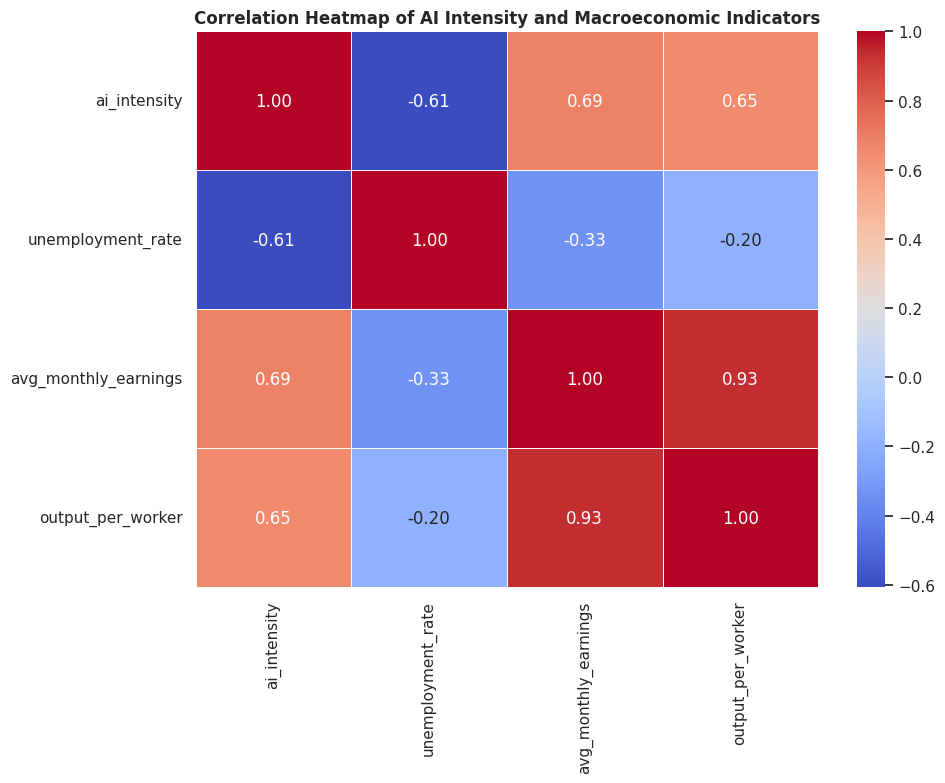

Saved: correlation_heatmap.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = analysis[['ai_intensity', 'unemployment_rate', 'avg_monthly_earnings', 'output_per_worker']].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of AI Intensity and Macroeconomic Indicators', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")

In [12]:
print("\n" + "=" * 60)
print("STEP 8 — LAG ANALYSIS")
print("=" * 60)

# Create lagged AI intensity variables
# Shift 'ai_intensity' by 1 year (lag_1) and 2 years (lag_2)
analysis_lagged = analysis.copy()
analysis_lagged['ai_intensity_lag1'] = analysis_lagged['ai_intensity'].shift(1)
analysis_lagged['ai_intensity_lag2'] = analysis_lagged['ai_intensity'].shift(2)

print("\nAnalysis DataFrame with Lagged AI Intensity:")
print(analysis_lagged[['Year', 'ai_intensity', 'ai_intensity_lag1', 'ai_intensity_lag2', 'unemployment_rate']].to_string(index=False))

# Drop rows with NaN values resulting from the shift for regression analysis
analysis_lagged = analysis_lagged.dropna()

# --- Correlations with Lagged AI Intensity ---
print("\n" + "=" * 60)
print("Correlations with Lagged AI Adoption Intensity")
print("=" * 60)

targets = {
    'Unemployment Rate':    'unemployment_rate',
    'Avg Monthly Earnings': 'avg_monthly_earnings',
    'Output per Worker':    'output_per_worker',
}

for label, col in targets.items():
    r_lag1 = analysis_lagged['ai_intensity_lag1'].corr(analysis_lagged[col])
    r_lag2 = analysis_lagged['ai_intensity_lag2'].corr(analysis_lagged[col])
    print(f"  {label:<28}  r (lag1) = {r_lag1:+.4f}  r (lag2) = {r_lag2:+.4f}")

# --- OLS Regressions with Lagged AI Intensity ---
print("\n" + "=" * 60)
print("OLS Regressions with Lagged AI Adoption Intensity")
print("=" * 60)

# Lag 1
X_lag1 = sm.add_constant(analysis_lagged['ai_intensity_lag1'])
model_unemp_lag1 = sm.OLS(analysis_lagged['unemployment_rate'], X_lag1).fit()
print("\n[Model 5] Unemployment Rate ~ AI Adoption Intensity (Lag 1)")
print(f"  R²     = {model_unemp_lag1.rsquared:.4f}")
print(f"  Coef.  = {model_unemp_lag1.params['ai_intensity_lag1']:.4f}  " +
      f"(p = {model_unemp_lag1.pvalues['ai_intensity_lag1']:.4f})")

model_wages_lag1 = sm.OLS(analysis_lagged['avg_monthly_earnings'], X_lag1).fit()
print("\n[Model 6] Avg Monthly Earnings ~ AI Adoption Intensity (Lag 1)")
print(f"  R²     = {model_wages_lag1.rsquared:.4f}")
print(f"  Coef.  = {model_wages_lag1.params['ai_intensity_lag1']:.4f}  " +
      f"(p = {model_wages_lag1.pvalues['ai_intensity_lag1']:.4f})")

# Lag 2
X_lag2 = sm.add_constant(analysis_lagged['ai_intensity_lag2'])
model_unemp_lag2 = sm.OLS(analysis_lagged['unemployment_rate'], X_lag2).fit()
print("\n[Model 7] Unemployment Rate ~ AI Adoption Intensity (Lag 2)")
print(f"  R²     = {model_unemp_lag2.rsquared:.4f}")
print(f"  Coef.  = {model_unemp_lag2.params['ai_intensity_lag2']:.4f}  " +
      f"(p = {model_unemp_lag2.pvalues['ai_intensity_lag2']:.4f})")

model_wages_lag2 = sm.OLS(analysis_lagged['avg_monthly_earnings'], X_lag2).fit()
print("\n[Model 8] Avg Monthly Earnings ~ AI Adoption Intensity (Lag 2)")
print(f"  R²     = {model_wages_lag2.rsquared:.4f}")
print(f"  Coef.  = {model_wages_lag2.params['ai_intensity_lag2']:.4f}  " +
      f"(p = {model_wages_lag2.pvalues['ai_intensity_lag2']:.4f})")


STEP 8 — LAG ANALYSIS

Analysis DataFrame with Lagged AI Intensity:
 Year  ai_intensity  ai_intensity_lag1  ai_intensity_lag2  unemployment_rate
 2019      0.004410                NaN                NaN              3.669
 2020      0.005568           0.004410                NaN              8.055
 2021      0.015953           0.005568           0.004410              5.349
 2022      0.281711           0.015953           0.005568              3.650
 2023      0.325516           0.281711           0.015953              3.638
 2024      0.241414           0.325516           0.281711              4.022
 2025      0.229947           0.241414           0.325516              4.282

Correlations with Lagged AI Adoption Intensity
  Unemployment Rate             r (lag1) = -0.4412  r (lag2) = -0.0503
  Avg Monthly Earnings          r (lag1) = +0.8323  r (lag2) = +0.9376
  Output per Worker             r (lag1) = +0.7143  r (lag2) = +0.9657

OLS Regressions with Lagged AI Adoption Intensity

[M

### Visualizations for Lagged Analysis

In [13]:
print("\n" + "=" * 60)
print("STEP 9 — Visualizations for Lagged Analysis")
print("=" * 60)

# --- Chart 1: AI Intensity (Current and Lagged) vs. Unemployment ---
fig_unemp_lag, ax_unemp_lag = plt.subplots(figsize=(12, 7))
ax_unemp_lag.plot(analysis_lagged['Year'], analysis_lagged['unemployment_rate'],
                  color='#D0021B', marker='o', linewidth=2, label='Unemployment Rate (Current)')
ax_unemp_lag2 = ax_unemp_lag.twinx()
ax_unemp_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity'] * 100,
                   color='#1B365D', marker='s', linestyle='-', label='AI Intensity (Current)')
ax_unemp_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag1'] * 100,
                   color='#4CAF50', marker='^', linestyle='--', label='AI Intensity (Lag 1)')
ax_unemp_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag2'] * 100,
                   color='#FFC107', marker='D', linestyle=':', label='AI Intensity (Lag 2)')

ax_unemp_lag.set_title('AI Intensity (Current & Lagged) vs. Unemployment Rate', fontweight='bold')
ax_unemp_lag.set_xlabel('Year')
ax_unemp_lag.set_ylabel('Unemployment Rate (%)', color='#D0021B')
ax_unemp_lag2.set_ylabel('AI Adoption Intensity (%)', color='#1B365D')
ax_unemp_lag.tick_params(axis='y', labelcolor='#D0021B')
ax_unemp_lag2.tick_params(axis='y', labelcolor='#1B365D')

lines_unemp = ax_unemp_lag.get_lines() + ax_unemp_lag2.get_lines()
ax_unemp_lag.legend(lines_unemp, [l.get_label() for l in lines_unemp], loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('ai_lag_vs_unemployment.png', dpi=300, bbox_inches='tight')
plt.close(fig_unemp_lag)
print("Saved: ai_lag_vs_unemployment.png")

# --- Chart 2: AI Intensity (Current and Lagged) vs. Wages ---
fig_wages_lag, ax_wages_lag = plt.subplots(figsize=(12, 7))
ax_wages_lag.plot(analysis_lagged['Year'], analysis_lagged['avg_monthly_earnings'],
                 color='#F5A623', marker='o', linewidth=2, label='Avg Monthly Earnings (Current)')
ax_wages_lag2 = ax_wages_lag.twinx()
ax_wages_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity'] * 100,
                   color='#1B365D', marker='s', linestyle='-', label='AI Intensity (Current)')
ax_wages_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag1'] * 100,
                   color='#4CAF50', marker='^', linestyle='--', label='AI Intensity (Lag 1)')
ax_wages_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag2'] * 100,
                   color='#FFC107', marker='D', linestyle=':', label='AI Intensity (Lag 2)')

ax_wages_lag.set_title('AI Intensity (Current & Lagged) vs. Average Monthly Earnings', fontweight='bold')
ax_wages_lag.set_xlabel('Year')
ax_wages_lag.set_ylabel('Avg Monthly Earnings (PPP $)', color='#F5A623')
ax_wages_lag2.set_ylabel('AI Adoption Intensity (%)', color='#1B365D')
ax_wages_lag.tick_params(axis='y', labelcolor='#F5A623')
ax_wages_lag2.tick_params(axis='y', labelcolor='#1B365D')

lines_wages = ax_wages_lag.get_lines() + ax_wages_lag2.get_lines()
ax_wages_lag.legend(lines_wages, [l.get_label() for l in lines_wages], loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('ai_lag_vs_wages.png', dpi=300, bbox_inches='tight')
plt.close(fig_wages_lag)
print("Saved: ai_lag_vs_wages.png")

# --- Chart 3: AI Intensity (Current and Lagged) vs. Productivity ---
fig_prod_lag, ax_prod_lag = plt.subplots(figsize=(12, 7))
ax_prod_lag.plot(analysis_lagged['Year'], analysis_lagged['output_per_worker'],
                 color='#008080', marker='o', linewidth=2, label='Output per Worker (Current)')
ax_prod_lag2 = ax_prod_lag.twinx()
ax_prod_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity'] * 100,
                   color='#1B365D', marker='s', linestyle='-', label='AI Intensity (Current)')
ax_prod_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag1'] * 100,
                   color='#4CAF50', marker='^', linestyle='--', label='AI Intensity (Lag 1)')
ax_prod_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag2'] * 100,
                   color='#FFC107', marker='D', linestyle=':', label='AI Intensity (Lag 2)')

ax_prod_lag.set_title('AI Intensity (Current & Lagged) vs. Output per Worker', fontweight='bold')
ax_prod_lag.set_xlabel('Year')
ax_prod_lag.set_ylabel('Output per Worker (PPP $)', color='#008080')
ax_prod_lag2.set_ylabel('AI Adoption Intensity (%)', color='#1B365D')
ax_prod_lag.tick_params(axis='y', labelcolor='#008080')
ax_prod_lag2.tick_params(axis='y', labelcolor='#1B365D')

lines_prod = ax_prod_lag.get_lines() + ax_prod_lag2.get_lines()
ax_prod_lag.legend(lines_prod, [l.get_label() for l in lines_prod], loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('ai_lag_vs_productivity.png', dpi=300, bbox_inches='tight')
plt.close(fig_prod_lag)
print("Saved: ai_lag_vs_productivity.png")


STEP 9 — Visualizations for Lagged Analysis
Saved: ai_lag_vs_unemployment.png
Saved: ai_lag_vs_wages.png
Saved: ai_lag_vs_productivity.png


RE-GENERATING ALL CHARTS FOR INLINE DISPLAY


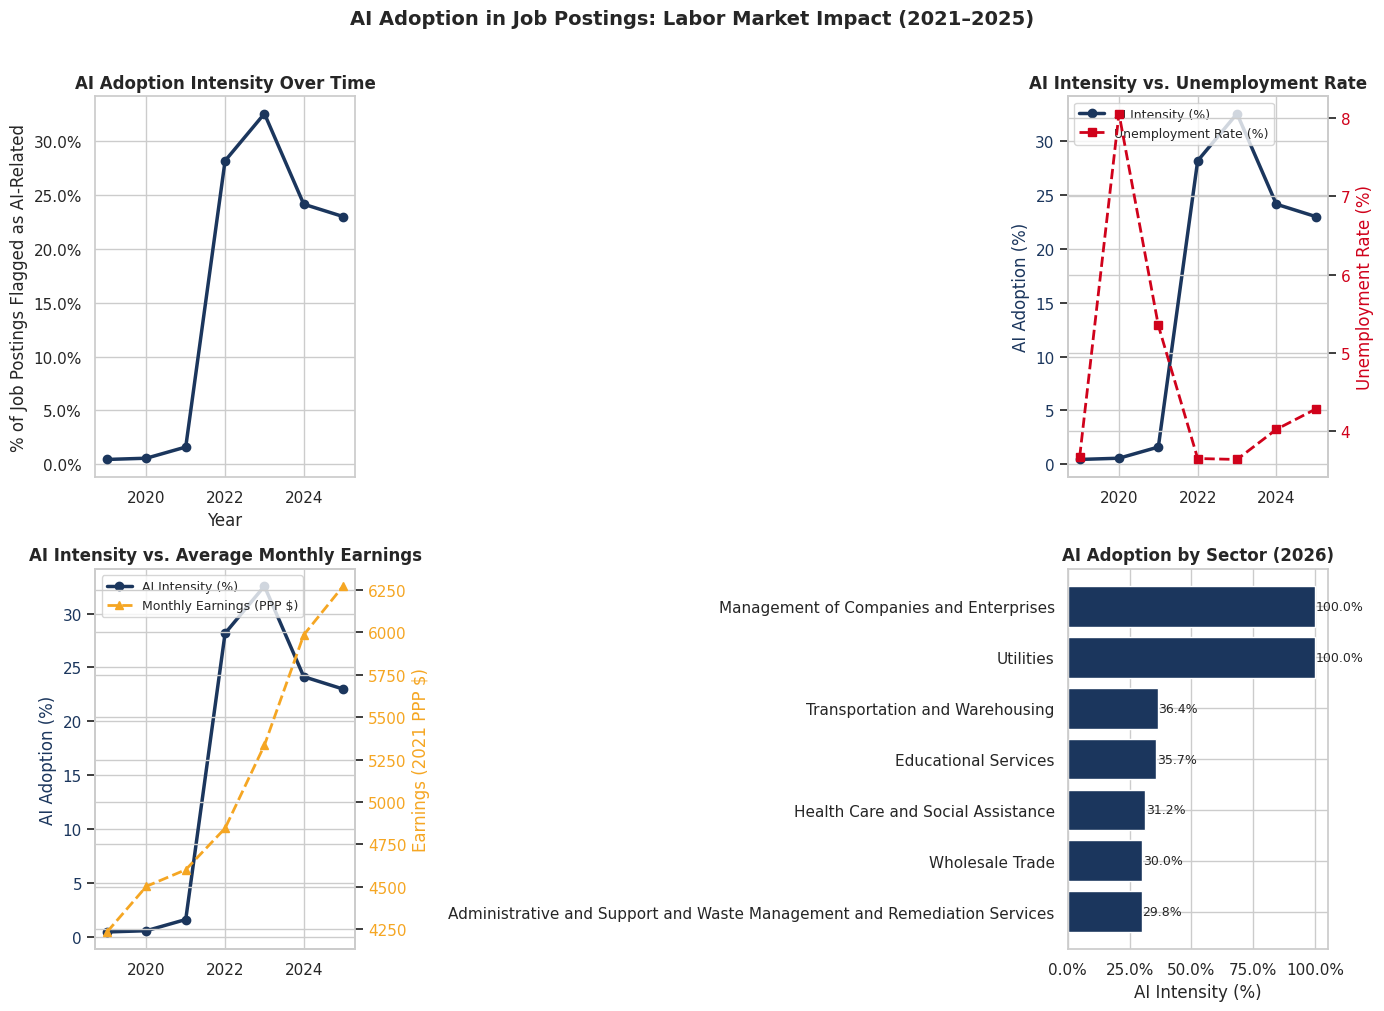


--- Correlation Heatmap ---


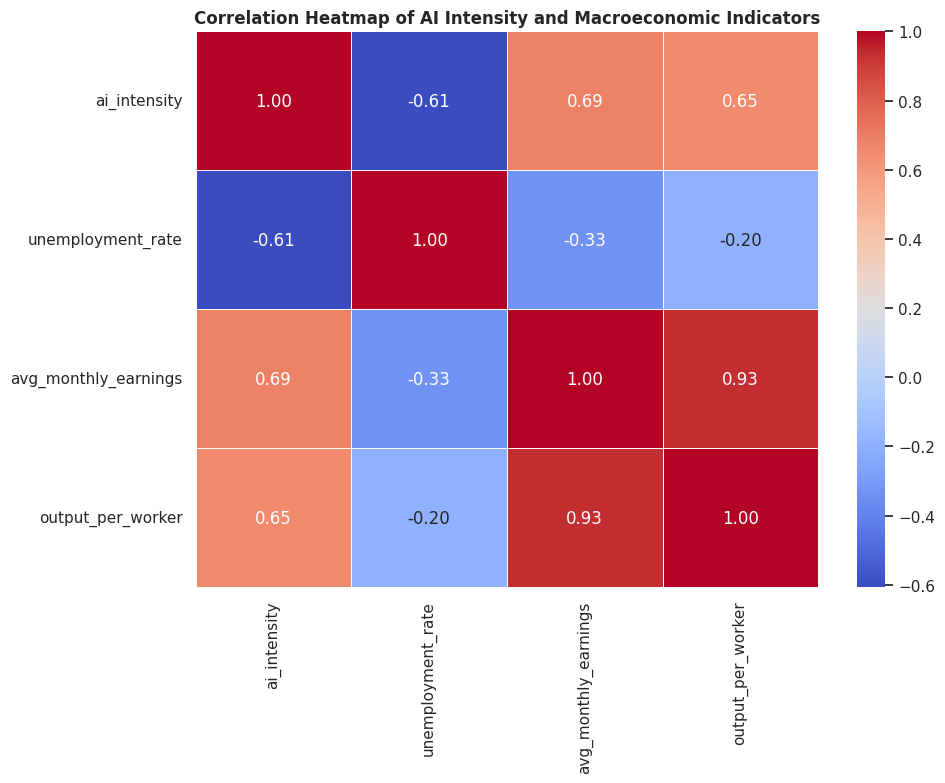


--- Lagged Analysis Visualizations (originally from earlier step) ---


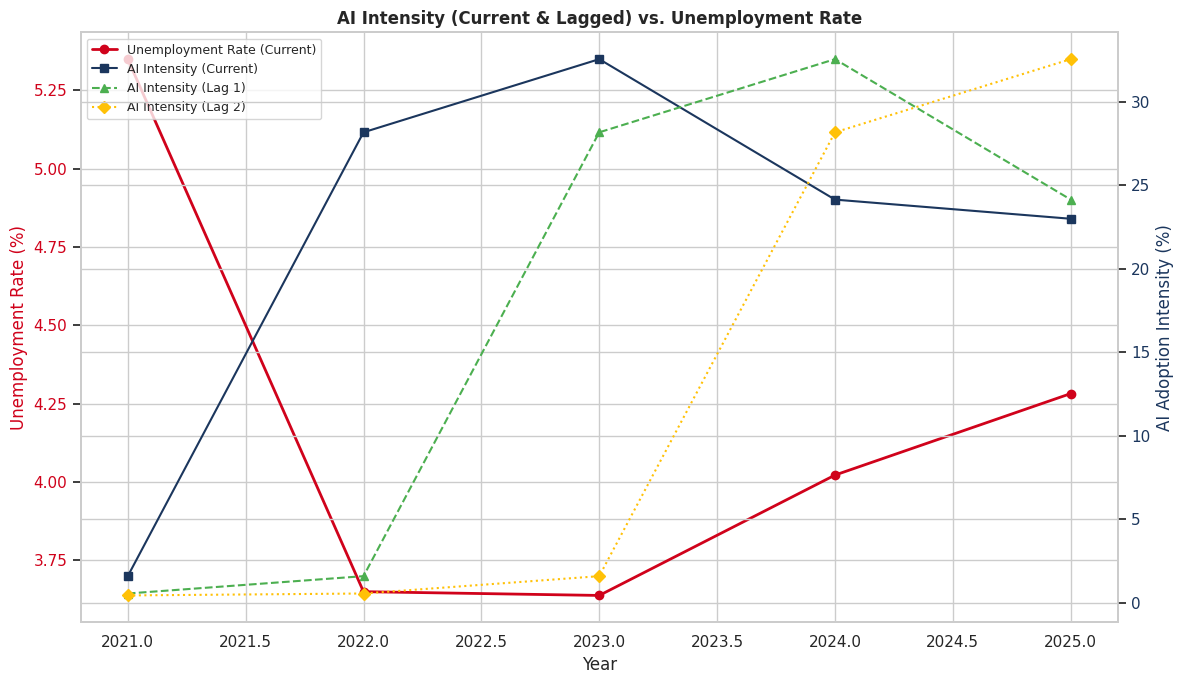

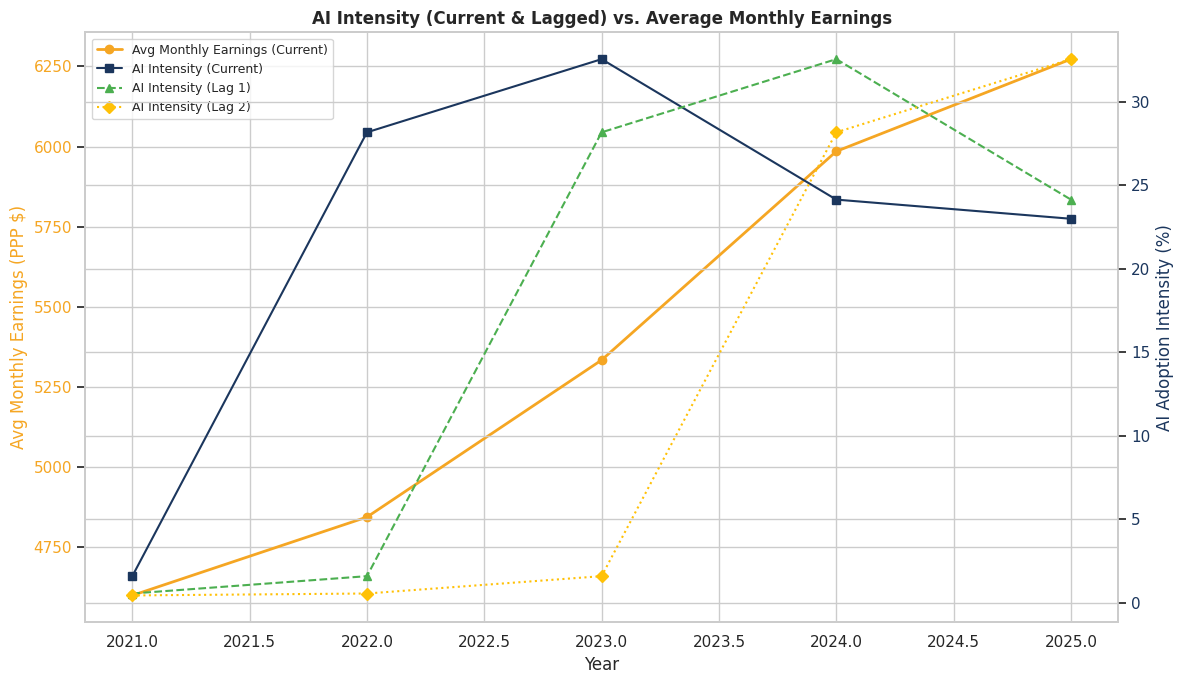

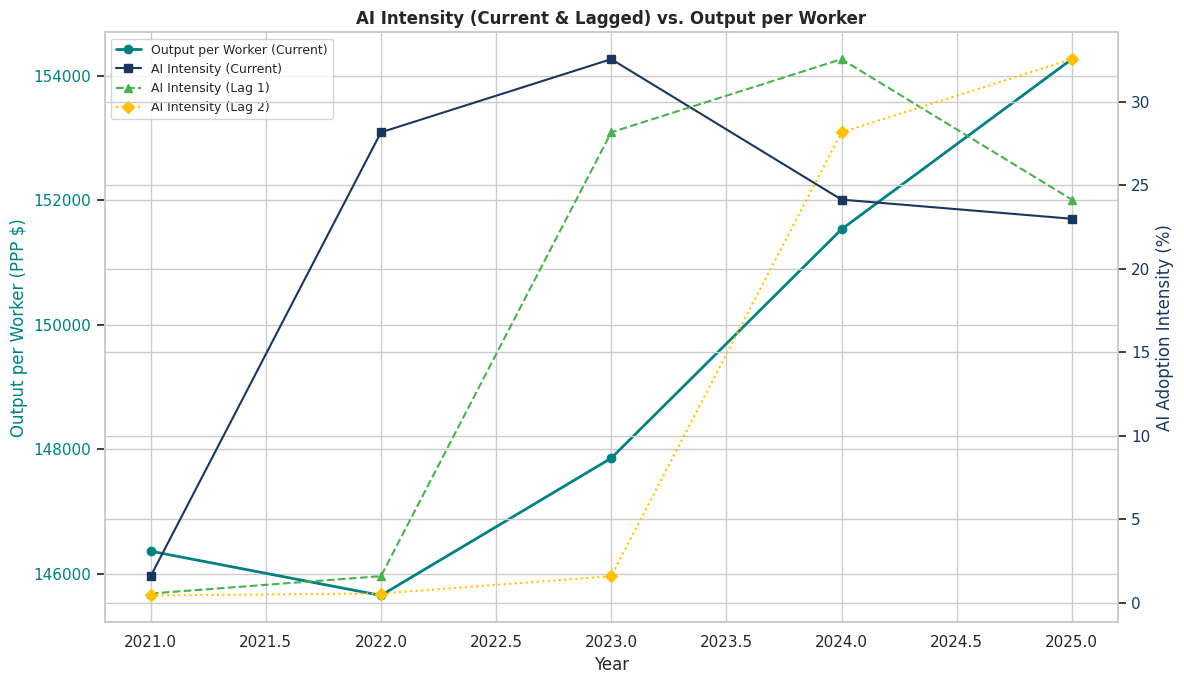


All visualizations have been displayed inline.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("RE-GENERATING ALL CHARTS FOR INLINE DISPLAY")
print("=" * 60)

# --- Dashboard Visualizations (originally from STEP 7) ---
fig_dashboard, axes = plt.subplots(2, 2, figsize=(14, 10))
fig_dashboard.suptitle('AI Adoption in Job Postings: Labor Market Impact (2021–2025)',
             fontsize=14, fontweight='bold', y=1.01)

# Chart 1: AI Intensity trend
ax = axes[0, 0]
ax.plot(analysis['Year'], analysis['ai_intensity'] * 100,
        color='#1B365D', marker='o', linewidth=2.5)
ax.set_title('AI Adoption Intensity Over Time', fontweight='bold')
ax.set_ylabel('% of Job Postings Flagged as AI-Related')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}%'))

# Chart 2: AI Intensity vs Unemployment
ax = axes[0, 1]
ax2 = ax.twinx()
ax.plot(analysis['Year'], analysis['ai_intensity'] * 100,
        color='#1B365D', marker='o', linewidth=2.5, label='AI Intensity (%)')
ax2.plot(analysis['Year'], analysis['unemployment_rate'],
         color='#D0021B', marker='s', linestyle='--', linewidth=2, label='Unemployment Rate (%)')
ax.set_title('AI Intensity vs. Unemployment Rate', fontweight='bold')
ax.set_ylabel('AI Adoption (%)', color='#1B365D')
ax2.set_ylabel('Unemployment Rate (%)', color='#D0021B')
ax.tick_params(axis='y', labelcolor='#1B365D')
ax2.tick_params(axis='y', labelcolor='#D0021B')
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=9)

# Chart 3: AI Intensity vs Wages
ax = axes[1, 0]
ax2 = ax.twinx()
ax.plot(analysis['Year'], analysis['ai_intensity'] * 100,
        color='#1B365D', marker='o', linewidth=2.5, label='AI Intensity (%)')
ax2.plot(analysis['Year'], analysis['avg_monthly_earnings'],
         color='#F5A623', marker='^', linestyle='--', linewidth=2, label='Monthly Earnings (PPP $)')
ax.set_title('AI Intensity vs. Average Monthly Earnings', fontweight='bold')
ax.set_ylabel('AI Adoption (%)', color='#1B365D')
ax2.set_ylabel('Earnings (2021 PPP $)', color='#F5A623')
ax.tick_params(axis='y', labelcolor='#1B365D')
ax2.tick_params(axis='y', labelcolor='#F5A623')
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=9)

# Chart 4: Sector AI Intensity Bar
ax = axes[1, 1]
latest_year = df['YEAR(POSTED)'].max()
sector_plot = sector_latest.head(7).sort_values('ai_intensity')
bars = ax.barh(sector_plot['NAICS2_NAME'], sector_plot['ai_intensity'] * 100,
               color='#1B365D')
ax.set_title(f'AI Adoption by Sector ({latest_year})', fontweight='bold')
ax.set_xlabel('AI Intensity (%)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}%'))
for bar, val in zip(bars, sector_plot['ai_intensity'] * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show() # Display the dashboard plot
plt.close(fig_dashboard)

print("\n--- Correlation Heatmap ---")
# --- Correlation Heatmap (originally from earlier step) ---
correlation_matrix = analysis[['ai_intensity', 'unemployment_rate', 'avg_monthly_earnings', 'output_per_worker']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of AI Intensity and Macroeconomic Indicators', fontweight='bold')
plt.tight_layout()
plt.show() # Display the heatmap
plt.close()

print("\n--- Lagged Analysis Visualizations (originally from earlier step) ---")
# --- Chart 1: AI Intensity (Current and Lagged) vs. Unemployment ---
fig_unemp_lag, ax_unemp_lag = plt.subplots(figsize=(12, 7))
ax_unemp_lag.plot(analysis_lagged['Year'], analysis_lagged['unemployment_rate'],
                  color='#D0021B', marker='o', linewidth=2, label='Unemployment Rate (Current)')
ax_unemp_lag2 = ax_unemp_lag.twinx()
ax_unemp_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity'] * 100,
                   color='#1B365D', marker='s', linestyle='-', label='AI Intensity (Current)')
ax_unemp_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag1'] * 100,
                   color='#4CAF50', marker='^', linestyle='--', label='AI Intensity (Lag 1)')
ax_unemp_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag2'] * 100,
                   color='#FFC107', marker='D', linestyle=':', label='AI Intensity (Lag 2)')

ax_unemp_lag.set_title('AI Intensity (Current & Lagged) vs. Unemployment Rate', fontweight='bold')
ax_unemp_lag.set_xlabel('Year')
ax_unemp_lag.set_ylabel('Unemployment Rate (%)', color='#D0021B')
ax_unemp_lag2.set_ylabel('AI Adoption Intensity (%)', color='#1B365D')
ax_unemp_lag.tick_params(axis='y', labelcolor='#D0021B')
ax_unemp_lag2.tick_params(axis='y', labelcolor='#1B365D')

lines_unemp = ax_unemp_lag.get_lines() + ax_unemp_lag2.get_lines()
ax_unemp_lag.legend(lines_unemp, [l.get_label() for l in lines_unemp], loc='upper left', fontsize=9)
plt.tight_layout()
plt.show() # Display unemployment lag plot
plt.close(fig_unemp_lag)

# --- Chart 2: AI Intensity (Current and Lagged) vs. Wages ---
fig_wages_lag, ax_wages_lag = plt.subplots(figsize=(12, 7))
ax_wages_lag.plot(analysis_lagged['Year'], analysis_lagged['avg_monthly_earnings'],
                 color='#F5A623', marker='o', linewidth=2, label='Avg Monthly Earnings (Current)')
ax_wages_lag2 = ax_wages_lag.twinx()
ax_wages_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity'] * 100,
                   color='#1B365D', marker='s', linestyle='-', label='AI Intensity (Current)')
ax_wages_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag1'] * 100,
                   color='#4CAF50', marker='^', linestyle='--', label='AI Intensity (Lag 1)')
ax_wages_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag2'] * 100,
                   color='#FFC107', marker='D', linestyle=':', label='AI Intensity (Lag 2)')

ax_wages_lag.set_title('AI Intensity (Current & Lagged) vs. Average Monthly Earnings', fontweight='bold')
ax_wages_lag.set_xlabel('Year')
ax_wages_lag.set_ylabel('Avg Monthly Earnings (PPP $)', color='#F5A623')
ax_wages_lag2.set_ylabel('AI Adoption Intensity (%)', color='#1B365D')
ax_wages_lag.tick_params(axis='y', labelcolor='#F5A623')
ax_wages_lag2.tick_params(axis='y', labelcolor='#1B365D')

lines_wages = ax_wages_lag.get_lines() + ax_wages_lag2.get_lines()
ax_wages_lag.legend(lines_wages, [l.get_label() for l in lines_wages], loc='upper left', fontsize=9)
plt.tight_layout()
plt.show() # Display wages lag plot
plt.close(fig_wages_lag)

# --- Chart 3: AI Intensity (Current and Lagged) vs. Productivity ---
fig_prod_lag, ax_prod_lag = plt.subplots(figsize=(12, 7))
ax_prod_lag.plot(analysis_lagged['Year'], analysis_lagged['output_per_worker'],
                 color='#008080', marker='o', linewidth=2, label='Output per Worker (Current)')
ax_prod_lag2 = ax_prod_lag.twinx()
ax_prod_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity'] * 100,
                   color='#1B365D', marker='s', linestyle='-', label='AI Intensity (Current)')
ax_prod_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag1'] * 100,
                   color='#4CAF50', marker='^', linestyle='--', label='AI Intensity (Lag 1)')
ax_prod_lag2.plot(analysis_lagged['Year'], analysis_lagged['ai_intensity_lag2'] * 100,
                   color='#FFC107', marker='D', linestyle=':', label='AI Intensity (Lag 2)')

ax_prod_lag.set_title('AI Intensity (Current & Lagged) vs. Output per Worker', fontweight='bold')
ax_prod_lag.set_xlabel('Year')
ax_prod_lag.set_ylabel('Output per Worker (PPP $)', color='#008080')
ax_prod_lag2.set_ylabel('AI Adoption Intensity (%)', color='#1B365D')
ax_prod_lag.tick_params(axis='y', labelcolor='#008080')
ax_prod_lag2.tick_params(axis='y', labelcolor='#1B365D')

lines_prod = ax_prod_lag.get_lines() + ax_prod_lag2.get_lines()
ax_prod_lag.legend(lines_prod, [l.get_label() for l in lines_prod], loc='upper left', fontsize=9)
plt.tight_layout()
plt.show() # Display productivity lag plot
plt.close(fig_prod_lag)

print("\nAll visualizations have been displayed inline.")